<h1><center>Model variations - Learning curves</center></h1>
<center>This notebook purpose is to illustrate and analyze the learning curves of three model variations<center>

In [1]:
import numpy as np
import pandas as pd
import utils
from models import AnnLassoRegression

In [2]:
X_train = pd.read_csv(f"dataSets/dataSets1/s4/train-x.csv", header = None)
y_train = pd.read_csv(f"dataSets/dataSets1/s4/train-y.csv", header = None)

X_test = pd.read_csv(f"dataSets/dataSets1/s4/test-x.csv", header = None)
y_test = pd.read_csv(f"dataSets/dataSets1/s4/test-y.csv", header = None)

features = pd.read_csv(f"dataSets/dataSets1/s4/important_inds.csv")
features = features.values.flatten()

In [4]:
model_no_warmstart = AnnLassoRegression(name = "without warm start", warm_start=False)
model_warmstart_ista = AnnLassoRegression(name = "warm start, ista at each sd", warm_start=True, one_ista=False)
model_warmstart_no_ista = AnnLassoRegression(name = "warm start, ista only at end", warm_start=True, one_ista=True)

model_no_warmstart.fit(X_train, y_train, print_epochs=False)
model_warmstart_ista.fit(X_train, y_train, print_epochs=False)
model_warmstart_no_ista.fit(X_train, y_train, print_epochs=False)

MODEL FITTED !


Lambda path progress: 100%|██████████| 7/7 [02:02<00:00, 17.56s/it]


MODEL FITTED !


Lambda path progress: 100%|██████████| 7/7 [00:43<00:00,  6.25s/it]

MODEL FITTED !


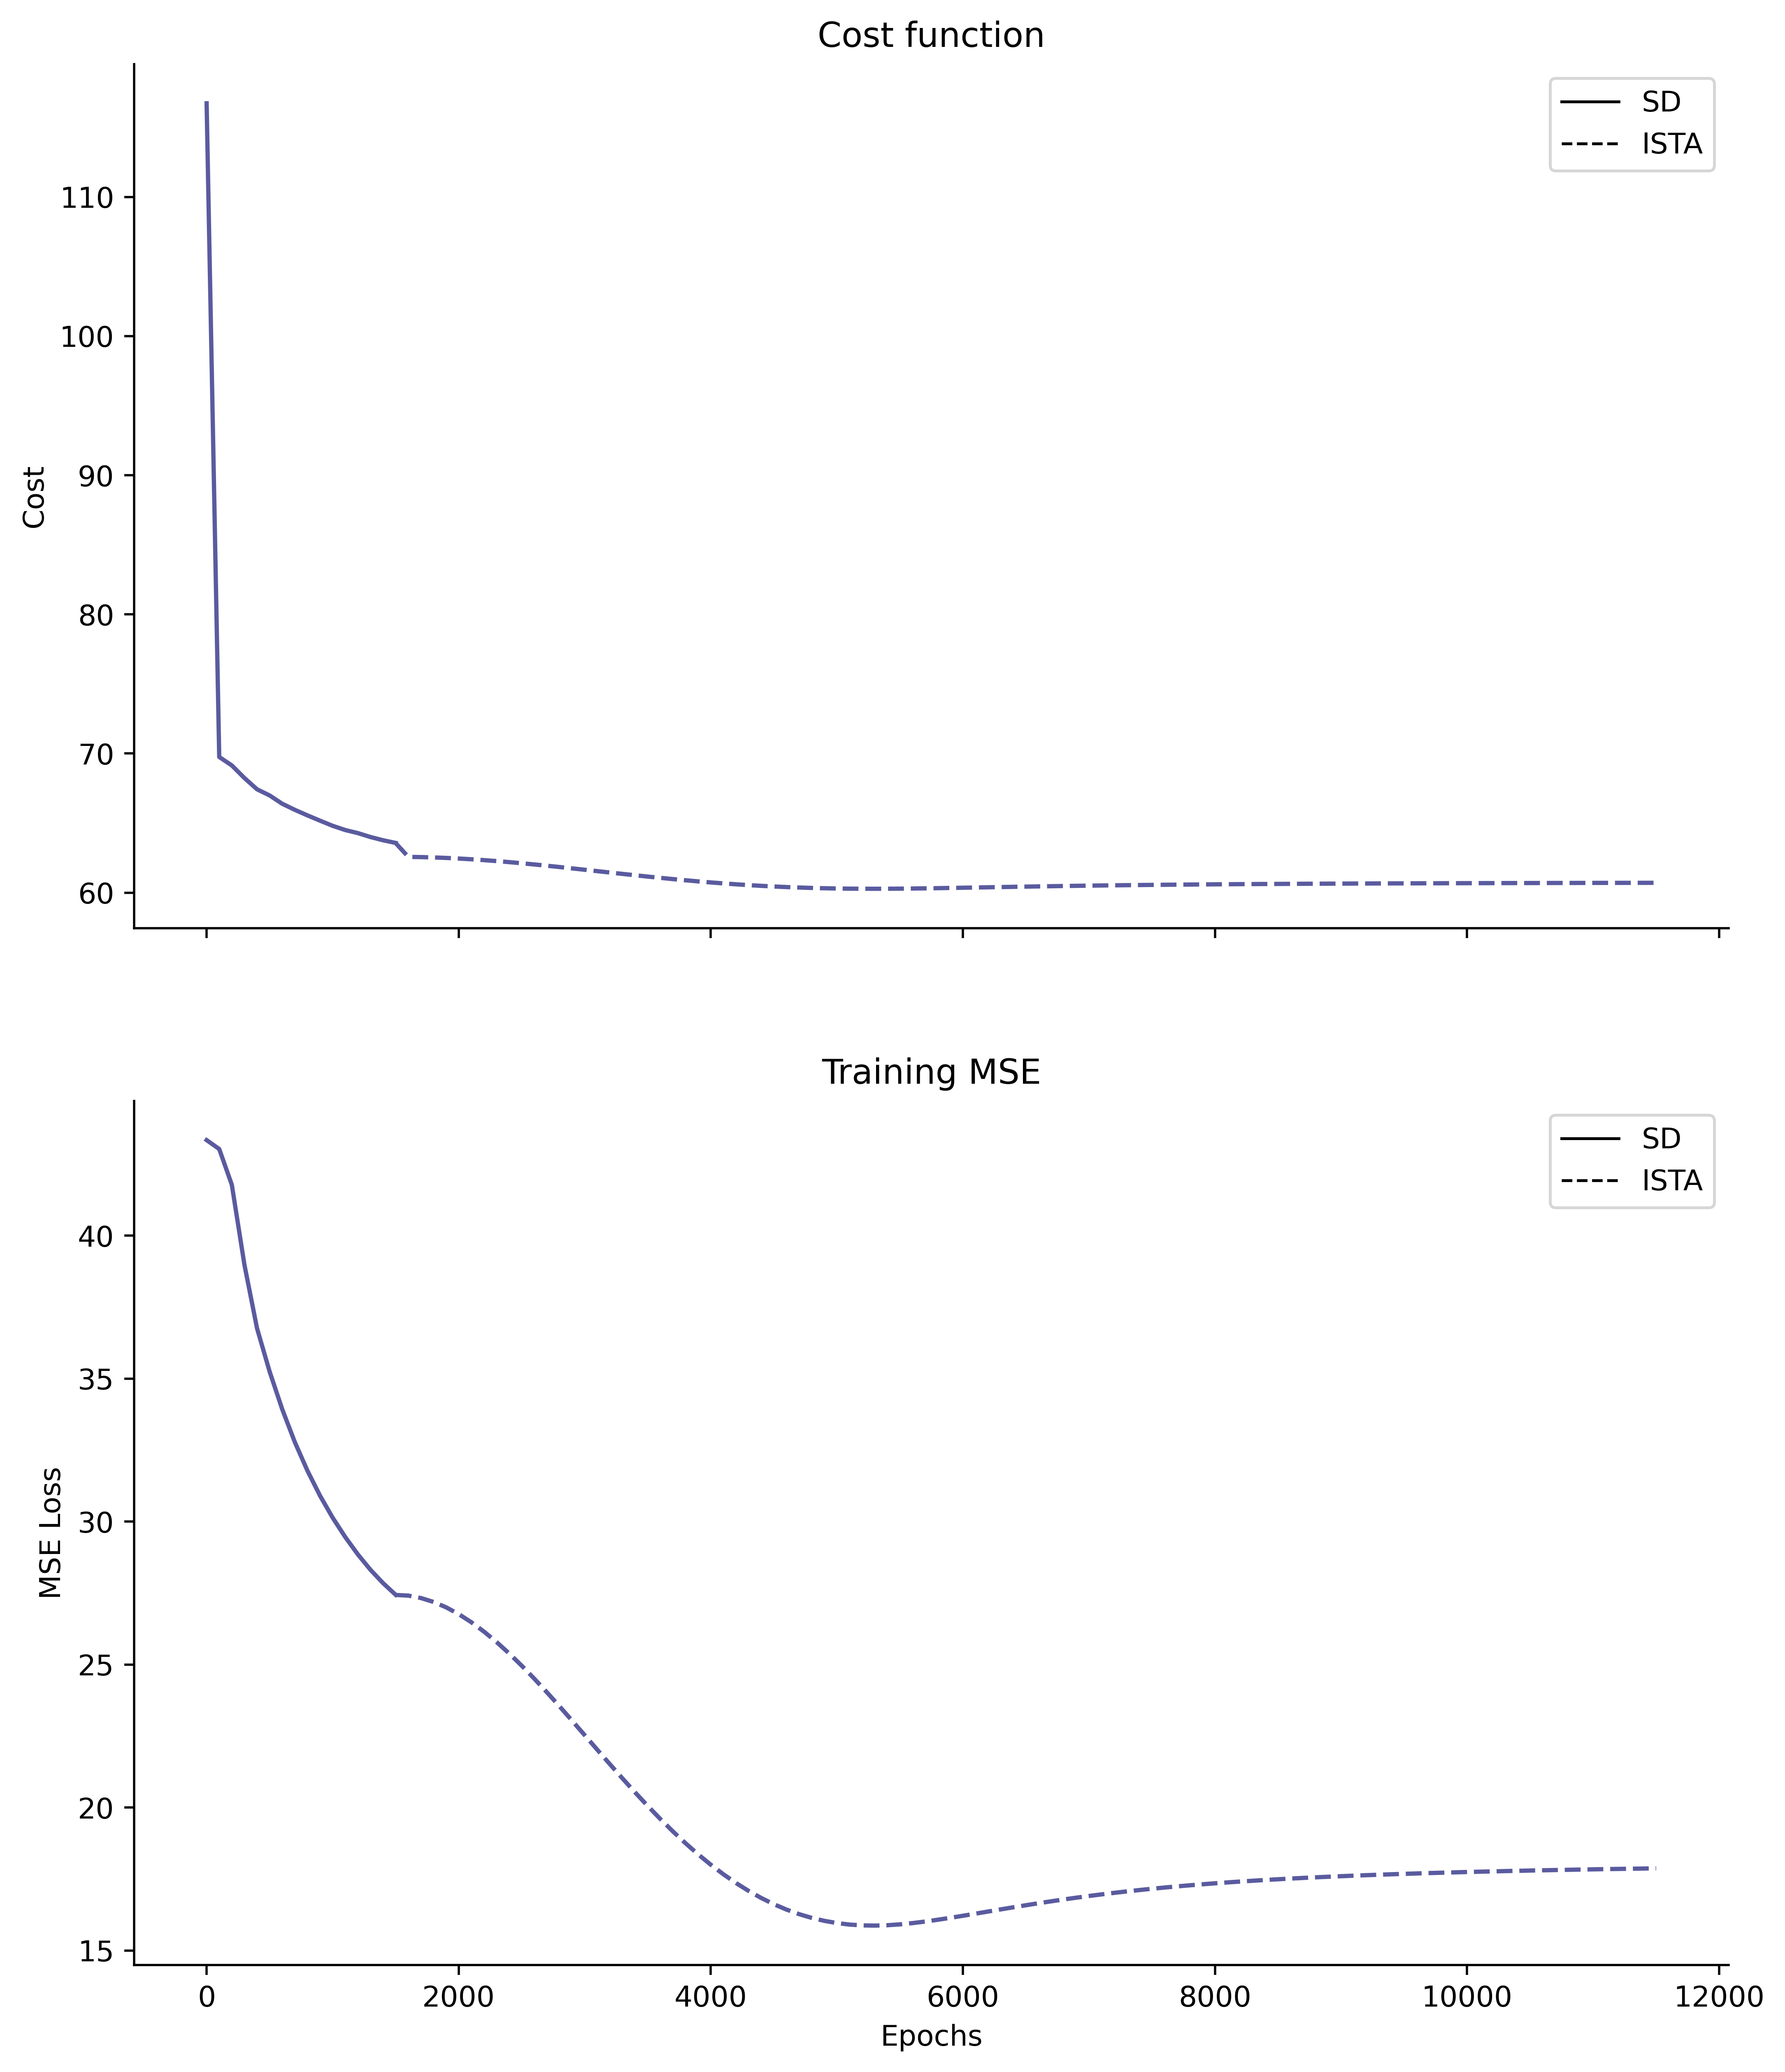

{'error': 24.07161403359365, 'TPR': 1.0, 'FDR': 0.0, 'exact_recovery': True}

In [8]:
model_no_warmstart.plot_learning_curve()
model_no_warmstart.results_analysis(X_test, y_test, features)

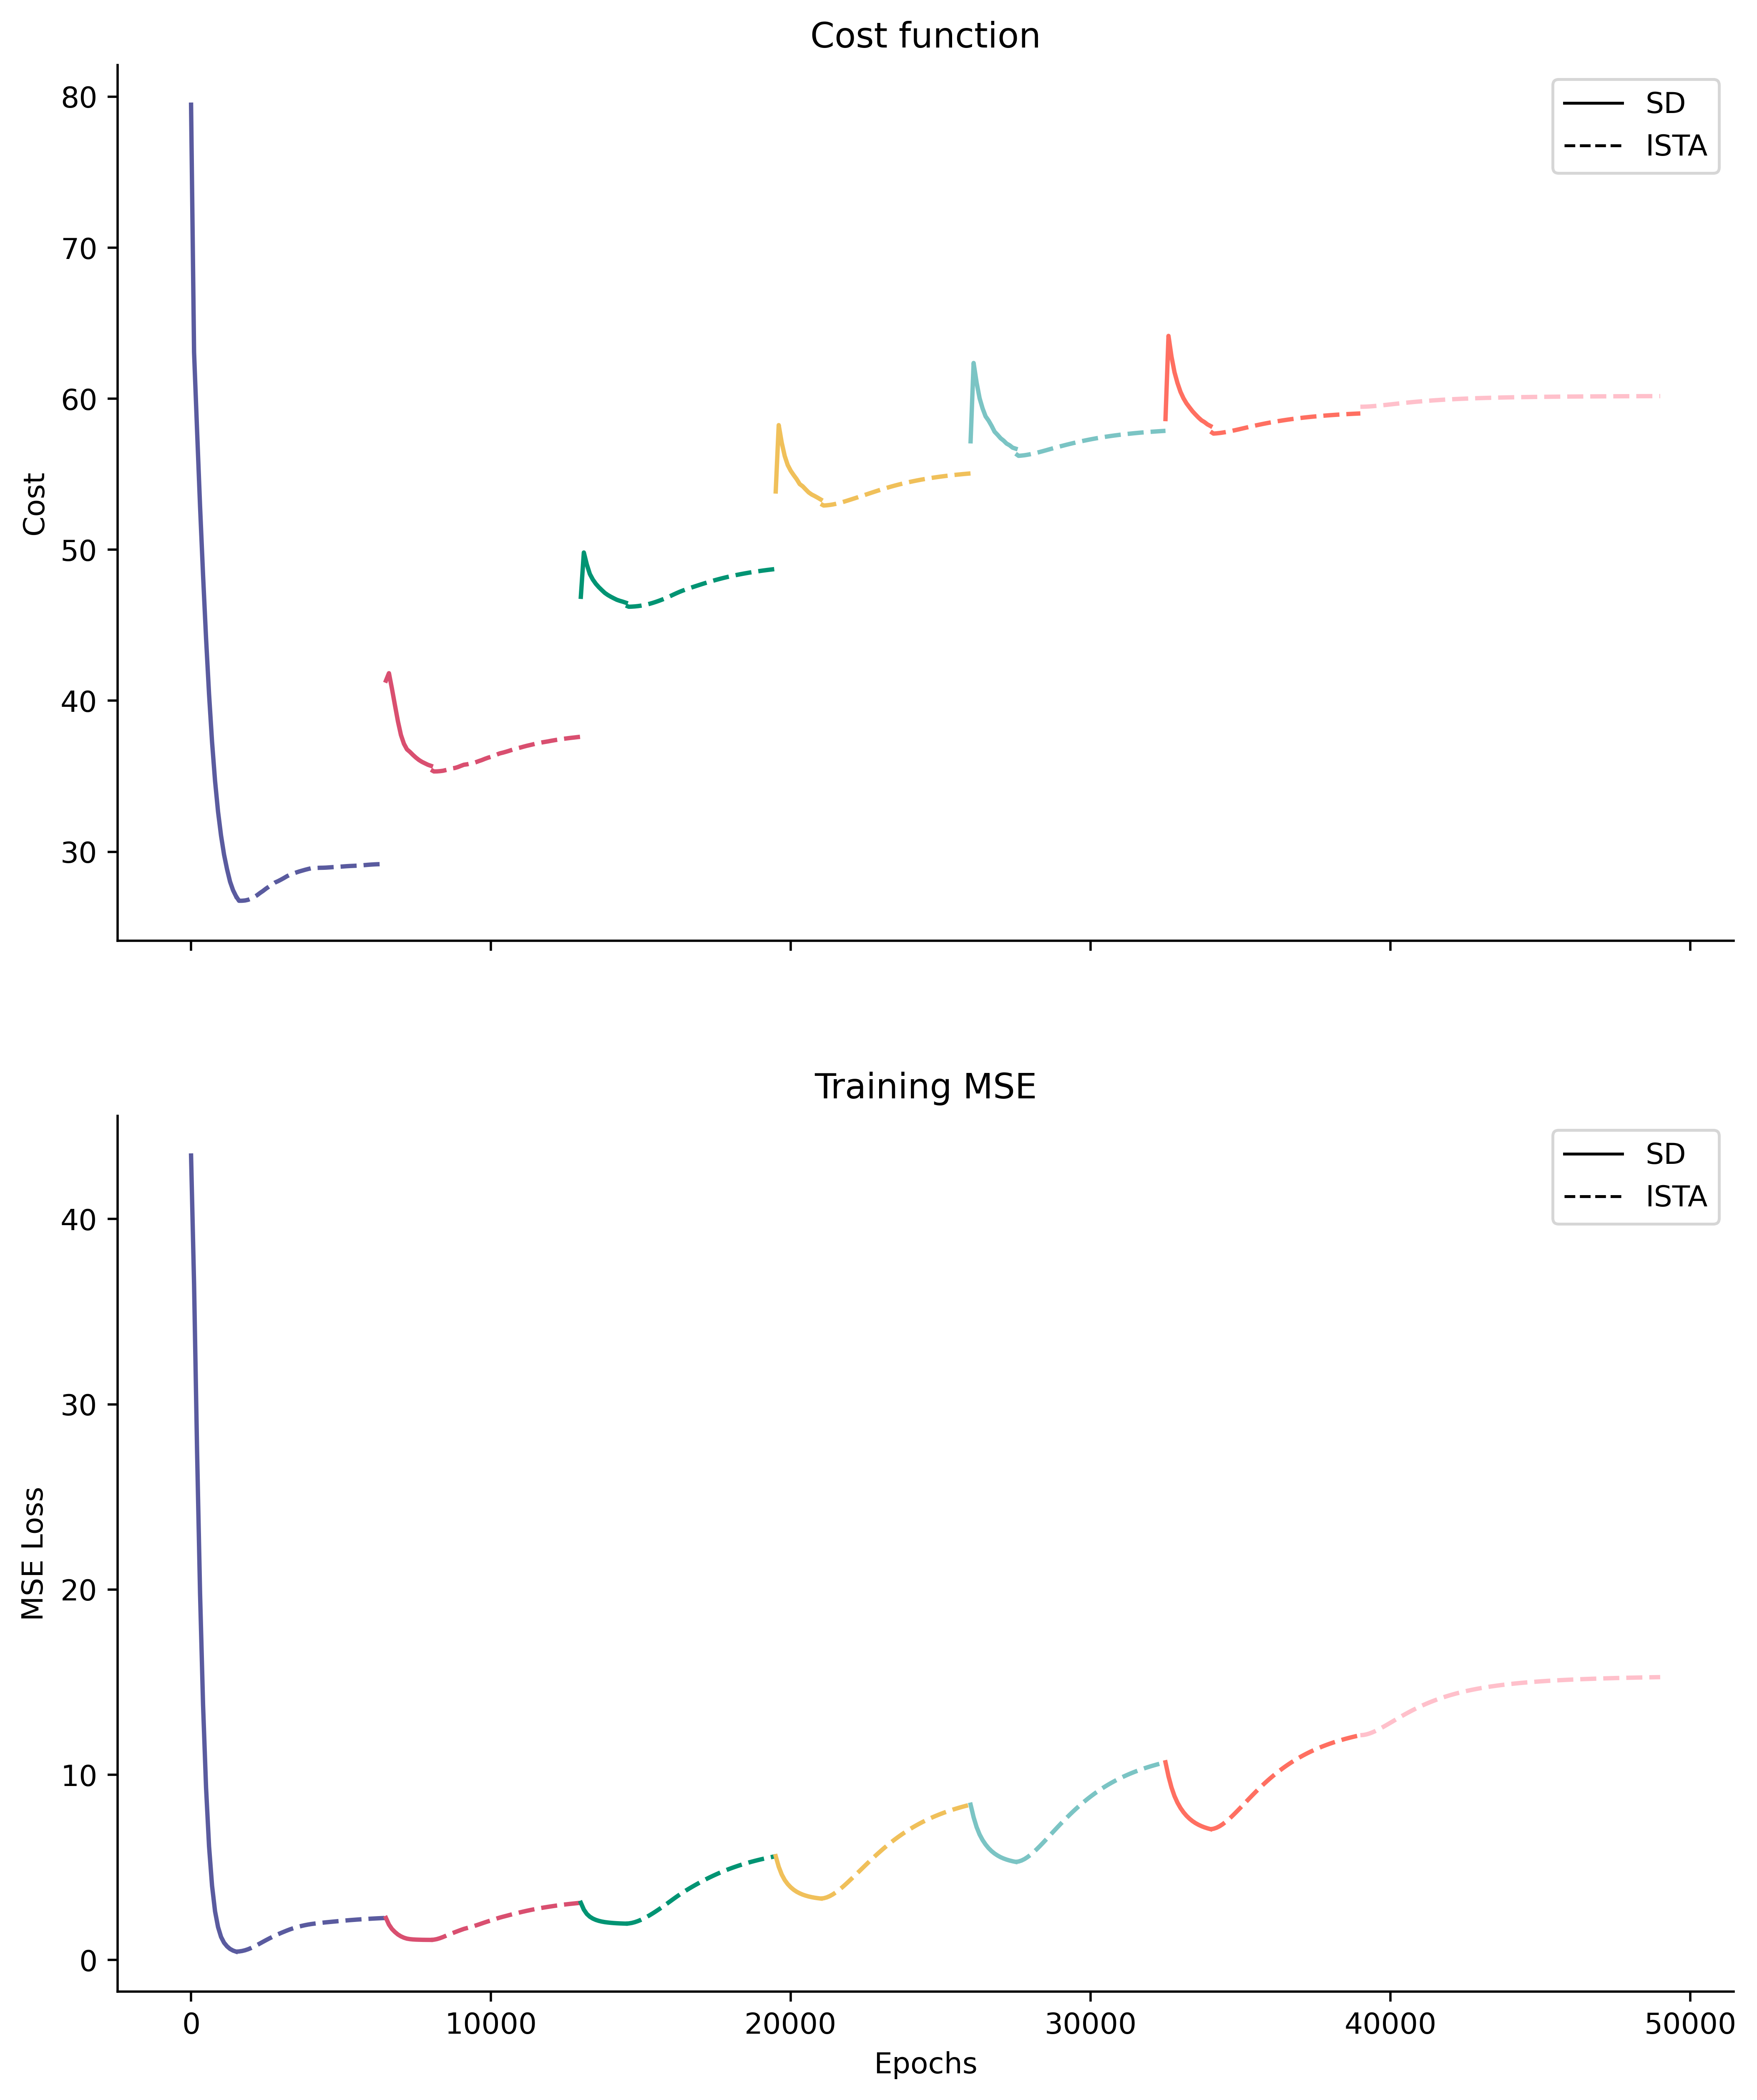

{'error': 22.10540752164005, 'TPR': 1.0, 'FDR': 0.0, 'exact_recovery': True}

In [9]:
model_warmstart_ista.plot_learning_curve()
model_warmstart_ista.results_analysis(X_test, y_test, features)

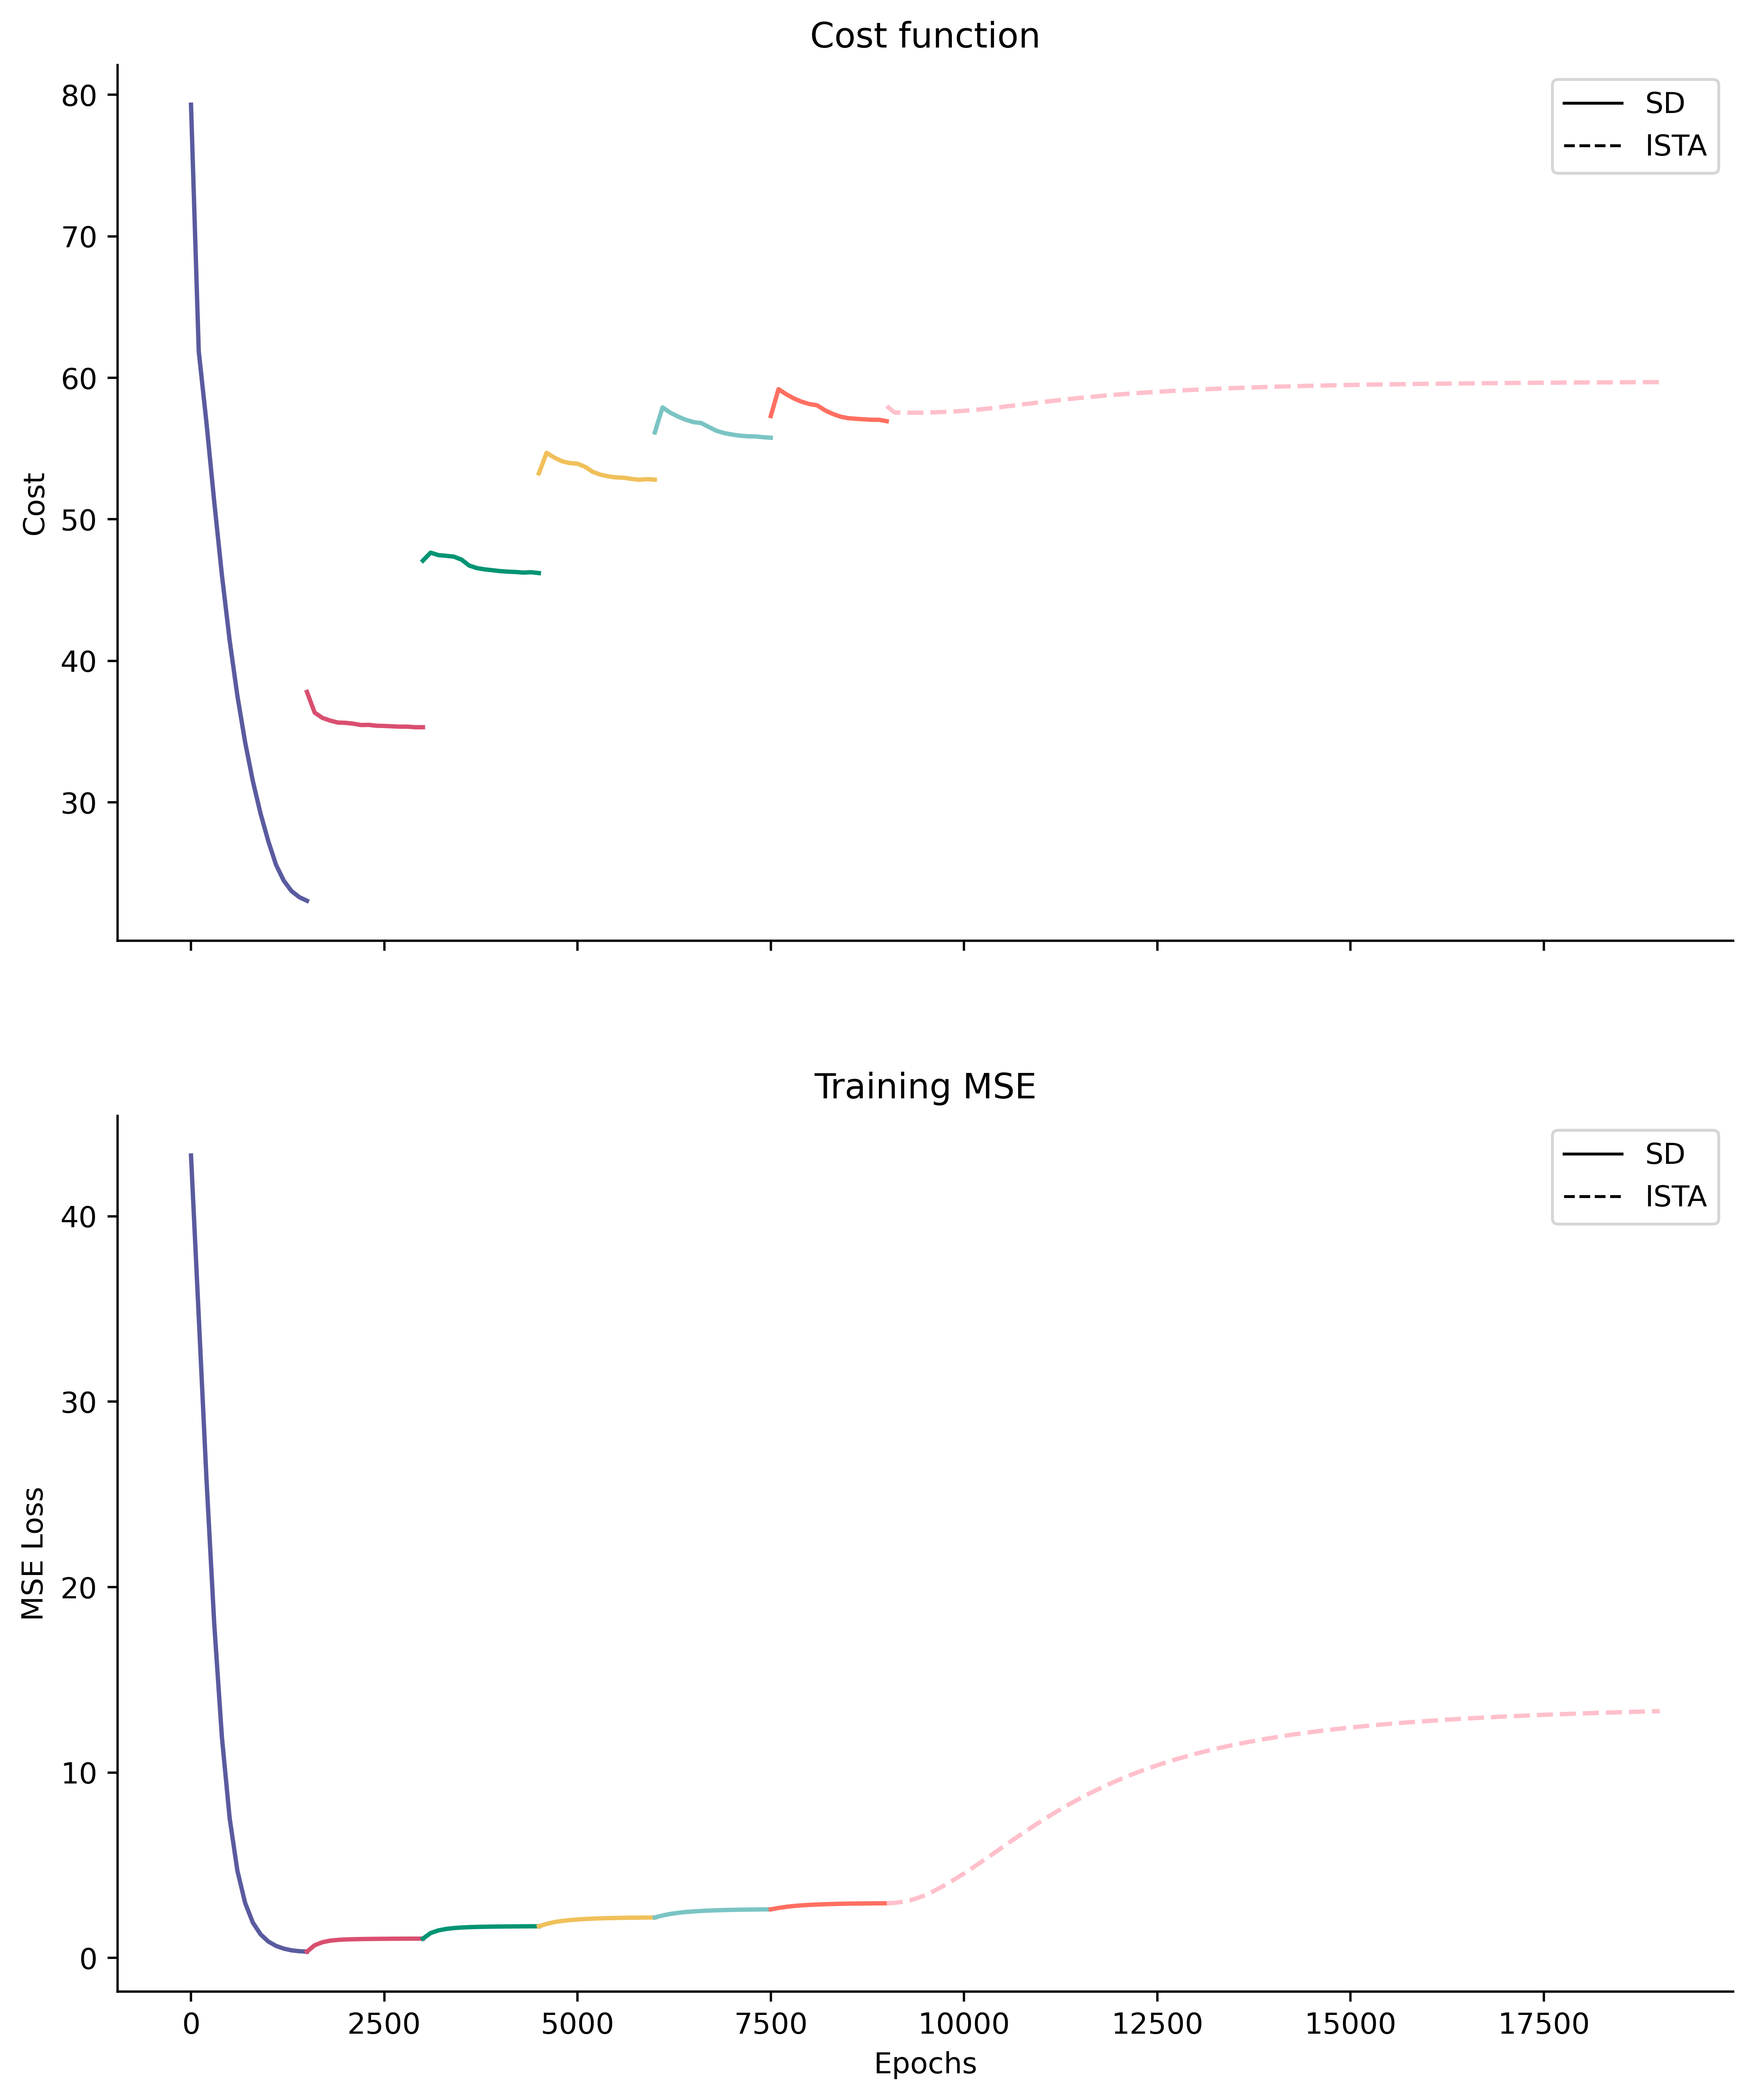

{'error': 20.552443666406123, 'TPR': 1.0, 'FDR': 0.0, 'exact_recovery': True}

In [10]:
model_warmstart_no_ista.plot_learning_curve()
model_warmstart_no_ista.results_analysis(X_test, y_test, features)

<center><h2>Notebook conclusions</h2></center>

The learning curves of the three model variations present similarities, with their final loss and MSE values being nearly identical.

1. **No Warm Start:**
   - This variation is more prone to getting trapped in local minima, diminishing its utility (refer to the phase transition notebook for details).
   - It appears to be the least effective among the three, judging by its final loss and MSE metrics.

2. **Warm Start with ISTA at Each Step:**
   - Benefits from implementing a warm start, thereby avoiding the risk of converging to a local minimum.
   - Requires a significantly higher number of epochs during training.
   - Suggests that the lambda parameter is overly conservative, leading to the identification of relevant features earlier than anticipated (set print_epochs to true for details).

3. **Warm Start with ISTA Only at the End:**
   - Stands out as the superior option in terms of final loss and MSE.
   - Demands fewer training epochs.
   - This version is likely the most advisable choice to proceed with.